# Faroe Islands TT stacking

Single-ship runner. Adjust file indices and config below, then run all cells.

In [ ]:
%load_ext autoreload
%autoreload 2

import glob
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from src.preprocessing import (
    extract_das_data,
    cable_depth_faroe,
    load_ais_faroe,
    preprocess_hdf5,
)
from src.tt_stacking import (
    run_stacking_loop,
    assign_y_sign_stacking,
)

from src.plotting import (
    plot_stacking_vs_ais, 
    plot_stacking_map,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# Paths 
DATA_DIR      = r"C:\Users\Lenovo\OneDrive - Danmarks Tekniske Universitet\Dokumenter\GitHub\DAS-BOOT-Localisation-of-Signals-in-Distributed-Acoustic-Sensing\data\faroe"
CABLE_GEOJSON = r"C:\Users\Lenovo\OneDrive - Danmarks Tekniske Universitet\Dokumenter\GitHub\DAS-BOOT-Localisation-of-Signals-in-Distributed-Acoustic-Sensing\data\cable_info\faroecable.geojson"
AIS_CSV       = r"C:\Users\Lenovo\OneDrive - Danmarks Tekniske Universitet\Dokumenter\GitHub\DAS-BOOT-Localisation-of-Signals-in-Distributed-Acoustic-Sensing\data\AIS\ais_faroe.csv"

# File indices (HDF5 files sorted alphabetically by name) 
SHIP_FILE_START  = 4
SHIP_FILE_END    = 34
NOISE_FILE_START = 0
NOISE_FILE_END   = 13

# Distance window 
DMIN_KM  = 17.5   # km
DMAX_KM  = 19.5   # km
OFFSET_M = -345   # m  calibration offset (negative = DAS reads too far)

# Preprocessing 
BANDPASS_LOW  = 4    # Hz
BANDPASS_HIGH = 100  # Hz
FK_VMIN       = 1400 # m/s
FK_VMAX       = 2000 # m/s
FK_SIGMA      = 50

# Stacking parameters
CROSSING_TIME_OVERRIDE = '092610'  # 'HHMMSS' to force crossing time, or None for auto-detect

STACKING_CFG = dict(
    window_ms       = 2000,
    step_ms         = 1000,
    c_w             = 1500.0,
    y_lower         = 3.0,
    y_upper         = 1000.0,
    dx_grid         = 10.0,
    dy_grid         = 10.0,
    ch_step         = 3,
    n_candidates    = 5,
    min_stack_snr   = None,
    kalman_sigma_ax = 0.05,
    kalman_sigma_ay = 1.5,
    kalman_sigma_rx = 50.0,
    kalman_sigma_ry = 5.0,
    x_max_drift     = 100.0,
    y_max_drift     = 100.0,
    v_max           = 10.0,
    x_fairway_lo    = None,
    x_fairway_hi    = None,
    use_mahal_gate  = True,
)

In [ ]:
# setup: file list, ship + noise data, AIS, cable depth 
file_paths = sorted(glob.glob(DATA_DIR + '/*.hdf5'))
print(f'Found {len(file_paths)} HDF5 files')

print('Loading ship data …')
ship_raw, ship_time_axis, distances, fs, dx, dt = extract_das_data(
    file_paths, SHIP_FILE_START, SHIP_FILE_END, DMIN_KM, DMAX_KM,
)

print('Loading noise reference …')
noise_raw, *_ = extract_das_data(
    file_paths, NOISE_FILE_START, NOISE_FILE_END, DMIN_KM, DMAX_KM,
)

distances = distances + OFFSET_M / 1000.0
print(f'Distances: {distances.min():.3f} – {distances.max():.3f} km  (offset {OFFSET_M:+d} m)')
print(f'fs={fs:.1f} Hz  dx={dx:.3f} m  dt={dt:.6f} s')

df_ais = load_ais_faroe(AIS_CSV)

depth_interp = cable_depth_faroe(CABLE_GEOJSON)
STACKING_CFG['depth_interp'] = depth_interp
print('Setup complete.')

Found 35 HDF5 files
Loading ship data …
Loaded files 4–33 (30 files) → shape (240000, 490),  300.0 s
Loading noise reference …
Loaded files 0–12 (13 files) → shape (104000, 490),  130.0 s
Distances: 17.156 – 19.154 km  (offset -345 m)
fs=800.0 Hz  dx=1.021 m  dt=0.001250 s
AIS: 181 points,  2024-05-12 09:23:00 – 09:29:00 UTC
Setup complete.


In [ ]:
# Preprocessing
ship_processed = preprocess_hdf5(
    ship_raw, noise_raw, fs, dx, dt,
    apply_detrend      = True,
    apply_channel_norm = True,
    apply_bp           = True, bp_low=BANDPASS_LOW, bp_high=BANDPASS_HIGH,
    apply_fk           = True, fk_params=dict(vmin=FK_VMIN, vmax=FK_VMAX, sigma=FK_SIGMA),
)
print(f'Processed shape: {ship_processed.shape}')

Processed shape: (240000, 490)


In [ ]:
# Stacking loop + y-sign assignment
df_stack = run_stacking_loop(
    inv_data  = ship_processed,
    time_axis = ship_time_axis,
    distances = distances,
    dt        = dt,
    **STACKING_CFG,
)
print(f'Stacking: {len(df_stack)} windows')

df_signed, crossing_time = assign_y_sign_stacking(
    df_stack,
    crossing_override = CROSSING_TIME_OVERRIDE,
)
print(f"Crossing: {pd.to_datetime(crossing_time).strftime('%H:%M:%S')} UTC")
print(f'Windows:  {len(df_signed)}')
df_signed.head()

Stacking windows: 100%|██████████| 298/298 [10:09<00:00,  2.04s/it] 


Stacking: 298 windows
Crossing: 09:26:10 UTC
Windows:  298


,x_m,y_m,t0_sample,stack_amplitude,pick_idx,ch_idx,x_spread,y_spread,x_median,y_median,...,x_kalman,vx_kalman,y_kalman,vy_kalman,time_center,window_start_idx,window_end_idx,snr,y_sign,y_signed
0,17506.000069,913.000000,253,0.245553,"[288, 285, 283, 281, 279, 277, 275, 273, 271, ...","[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...",8.944272,14.142136,17516.000069,903.000000,...,17516.016473,0.00000,902.946103,0.0,2024-05-12 09:23:46.732000+00:00,0,1600,4.167000,1.0,913.000000
1,17466.016473,832.946103,644,0.185237,"[674, 672, 669, 667, 665, 663, 662, 660, 658, ...","[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...",31.240999,33.823069,17466.016473,832.946103,...,17516.016473,0.00000,902.946103,0.0,2024-05-12 09:23:47.732000+00:00,800,2400,4.112163,1.0,832.946103
2,17426.016473,942.946103,523,0.205715,"[543, 541, 540, 538, 537, 535, 534, 533, 531, ...","[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...",35.440090,46.733286,17466.016473,972.946103,...,17516.016473,0.00000,902.946103,0.0,2024-05-12 09:23:48.732000+00:00,1600,3200,4.147297,1.0,942.946103
3,17516.016473,972.946103,421,0.190956,"[455, 453, 451, 449, 447, 445, 443, 441, 439, ...","[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...",25.768197,46.043458,17526.016473,962.946103,...,17524.329452,0.22883,939.777386,10.0,2024-05-12 09:23:49.732000+00:00,2400,4000,4.154858,1.0,972.946103
4,17504.558282,849.777386,585,0.249930,"[622, 619, 617, 615, 612, 610, 608, 606, 604, ...","[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...",16.000000,14.696938,17484.558282,859.777386,...,17524.558282,0.22883,949.777386,10.0,2024-05-12 09:23:50.732000+00:00,3200,4800,4.158511,1.0,849.777386


c:\Users\Lenovo\OneDrive - Danmarks Tekniske Universitet\Dokumenter\GitHub\DAS-BOOT-Localisation-of-Signals-in-Distributed-Acoustic-Sensing\src\plotting.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  color="orange", lw=2, zorder=3, label="x_kalman")


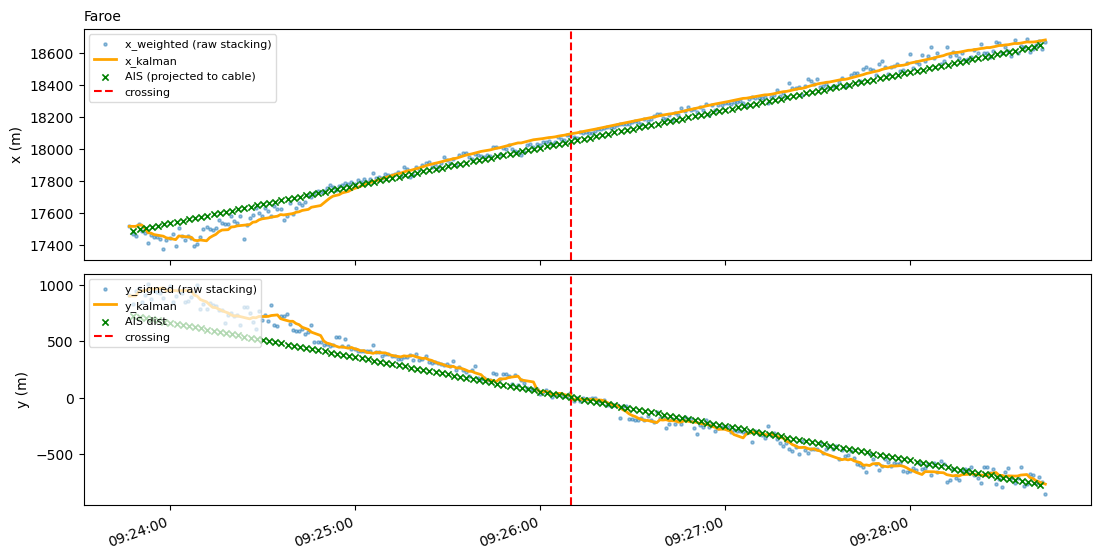

In [ ]:
fig = plot_stacking_vs_ais(
    df_signed          = df_signed,
    df_ais             = df_ais,
    crossing_time      = crossing_time,
    cable_geojson_path = CABLE_GEOJSON,
    ship_name          = 'Kapitan Nazin',
)
plt.show()

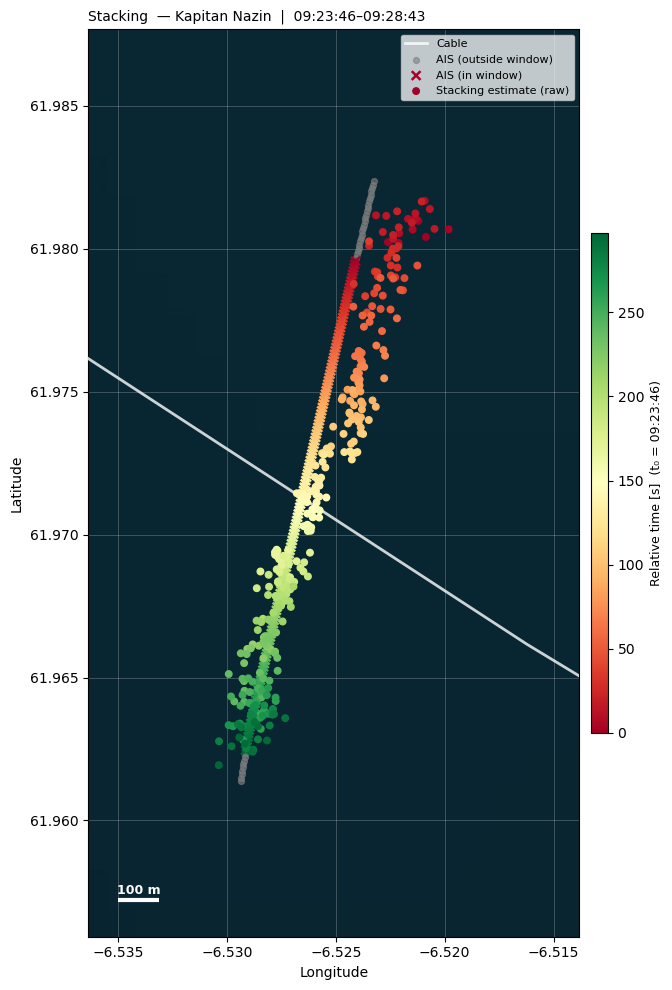

In [ ]:
fig = plot_stacking_map(
    df_signed          = df_signed,
    df_ais             = df_ais,
    crossing_time      = crossing_time,
    cable_geojson_path = CABLE_GEOJSON,
    ship_name          = 'Kapitan Nazin',
    show_kalman        = False,  # True to show Kalman-smoothed estimates instead of raw stacking
)
plt.show()
